# ProCAM — DEBIw Fix + Re-run
## Fixes the f1=0.5 / ba=1.0 degenerate result for DEBIw

**Root cause:** The resume notebook filtered `debiw_df[bdse_label in ['A','H']]` but  
the DEBIw manifest stores labels as `'A'` and `'N'` (not `'H'`).  
Only 1298 A-rows passed → all labels = 0 → trivial prediction.

**Fix:** Filter `['A','N']`, map A→0, N→1 (2-class: Angry vs Non-Angry/Happy).  
This gives all 5335 images with a real 2-class split.

**What this notebook runs:**
1. DEBIw ProCAM-noText (fixed)
2. DEBIw ProCAM-full (fixed)
3. Re-runs cross-dataset transfer for all pairs involving DEBIw
4. Saves complete merged results + all 3 figures


In [8]:
import subprocess, sys
subprocess.run([sys.executable, '-m', 'pip', 'install', '-q',
                'open_clip_torch', 'timm', 'scikit-learn', 'scipy', 'seaborn', 'tqdm'], check=True)

import os, random, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from PIL import Image
from tqdm.auto import tqdm
from concurrent.futures import ThreadPoolExecutor
import urllib.request

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as T
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import f1_score, balanced_accuracy_score
from sklearn.model_selection import train_test_split
import timm, open_clip

warnings.filterwarnings('ignore')
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {DEVICE} | {torch.cuda.get_device_name(0) if torch.cuda.is_available() else "CPU"}')


Device: cuda | Tesla T4


In [9]:
CFG = {
    'manifest_dir'       : '/kaggle/input/datasets/rohulaminlabid/benchmard-datasets',
    'shanbalico_dir'     : '/kaggle/input/datasets/danielshanbalico/dog-emotion/Dog Emotion',
    'devzohaib_dir'      : '/kaggle/input/datasets/devzohaib/dog-emotions-prediction/images',
    'debiw_img_dir'      : '/kaggle/input/datasets/rohulaminlabid/debiw-dataset',
    'out_dir'            : '/kaggle/working/procam_fixed_outputs',
    'seed': 42, 'test_split': 0.20, 'val_split': 0.10,
    'img_size': 224, 'batch_size': 64,
    'num_region_queries': 6, 'attn_heads': 4, 'attn_dropout': 0.1, 'hidden_dim': 256,
    'lr': 3e-4, 'weight_decay': 1e-4, 'epochs': 30, 'patience': 7, 'label_smoothing': 0.1,
    'ft_lr': 5e-5, 'ft_epochs': 15, 'ft_patience': 5, 'debiw_workers': 16,
}
random.seed(CFG['seed']); np.random.seed(CFG['seed']); torch.manual_seed(CFG['seed'])
if torch.cuda.is_available(): torch.cuda.manual_seed_all(CFG['seed'])
os.makedirs(CFG['out_dir'], exist_ok=True)
os.makedirs(CFG['debiw_img_dir'], exist_ok=True)

REGION_QUERIES = [
    'dog ears position and orientation showing emotional state',
    'dog mouth lips teeth and muzzle tension',
    'dog eyes gaze and orbital tension',
    'dog tail position carriage and movement',
    'dog overall body posture weight distribution and stance',
    'dog facial muscle tension and piloerection on neck',
]
print('Config ready.')


Config ready.


In [10]:
TRAIN_TF = T.Compose([
    T.Resize((CFG['img_size']+32, CFG['img_size']+32)),
    T.RandomCrop(CFG['img_size']), T.RandomHorizontalFlip(),
    T.ColorJitter(0.3, 0.3, 0.2, 0.05), T.ToTensor(),
    T.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225]),
])
VAL_TF = T.Compose([
    T.Resize((CFG['img_size'], CFG['img_size'])), T.ToTensor(),
    T.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225]),
])

class DogDS(Dataset):
    def __init__(self, paths, labels, tf=None):
        self.paths=list(paths); self.labels=list(labels); self.tf=tf
    def __len__(self): return len(self.paths)
    def __getitem__(self, i):
        try: img = Image.open(self.paths[i]).convert('RGB')
        except: img = Image.new('RGB',(224,224),(128,128,128))
        if self.tf: img = self.tf(img)
        return img, self.labels[i]

print('Transforms ready.')


Transforms ready.


In [11]:
class ProCAM(nn.Module):
    def __init__(self, num_classes, num_queries=6, hidden_dim=256,
                 attn_heads=4, attn_dropout=0.1,
                 use_text_init=True, text_query_embeddings=None):
        super().__init__()
        self.backbone = timm.create_model('vit_small_patch14_dinov2.lvd142m',
                                           pretrained=True, num_classes=0,
                                           img_size=224)          # ← FIX
        for p in self.backbone.parameters(): p.requires_grad_(False)
        D = self.backbone.num_features  # 384
        self.query_proj = nn.Linear(D, hidden_dim)
        self.key_proj   = nn.Linear(D, hidden_dim)
        self.val_proj   = nn.Linear(D, hidden_dim)
        if use_text_init and text_query_embeddings is not None:
            proj = nn.Linear(text_query_embeddings.shape[-1], D, bias=False)
            with torch.no_grad():
                init_q = proj(text_query_embeddings.float())
            self.region_queries = nn.Parameter(init_q)
        else:
            self.region_queries = nn.Parameter(torch.randn(num_queries, D)*0.02)
        self.cross_attn = nn.MultiheadAttention(hidden_dim, attn_heads,
                                                  dropout=attn_dropout, batch_first=True)
        self.ln_q  = nn.LayerNorm(hidden_dim)
        self.ln_kv = nn.LayerNorm(hidden_dim)
        self.head  = nn.Sequential(
            nn.Linear(hidden_dim*num_queries, hidden_dim),
            nn.GELU(), nn.Dropout(0.3), nn.Linear(hidden_dim, num_classes))

    def forward(self, x):
        B = x.size(0)
        with torch.no_grad(): feats = self.backbone.forward_features(x)
        patches = feats[:, 1:, :]   # 256 patch tokens
        K = self.ln_kv(self.key_proj(patches)); V = self.val_proj(patches)
        Q = self.ln_q(self.query_proj(self.region_queries.unsqueeze(0).expand(B,-1,-1)))
        att, _ = self.cross_attn(Q, K, V)
        return self.head(att.reshape(B, -1))


class ProCAM_noAttn(nn.Module):
    def __init__(self, num_classes, hidden_dim=256, **kw):
        super().__init__()
        self.backbone = timm.create_model('vit_small_patch14_dinov2.lvd142m',
                                           pretrained=True, num_classes=0,
                                           img_size=224)          # ← FIX
        for p in self.backbone.parameters(): p.requires_grad_(False)
        self.head = nn.Sequential(
            nn.Linear(self.backbone.num_features, hidden_dim),
            nn.GELU(), nn.Dropout(0.3), nn.Linear(hidden_dim, num_classes))
    def forward(self, x):
        with torch.no_grad(): feats = self.backbone.forward_features(x)
        return self.head(feats[:,1:,:].mean(1))

print('ProCAM ready.')

ProCAM ready.


In [12]:
def metrics(preds, trues, nc):
    labels = list(range(nc))
    return (float(f1_score(trues, preds, average='macro', labels=labels, zero_division=0)),
            float(balanced_accuracy_score(trues, preds)))

def train(model, tr_p, tr_l, va_p, va_l, nc, lr=None, epochs=None, patience=None):
    lr=lr or CFG['lr']; epochs=epochs or CFG['epochs']; patience=patience or CFG['patience']
    model=model.to(DEVICE)
    opt=torch.optim.AdamW(filter(lambda p:p.requires_grad, model.parameters()),
                            lr=lr, weight_decay=CFG['weight_decay'])
    sched=torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=epochs)
    crit=nn.CrossEntropyLoss(label_smoothing=CFG['label_smoothing'])
    tr_dl=DataLoader(DogDS(tr_p, tr_l, TRAIN_TF), batch_size=CFG['batch_size'],
                     shuffle=True, num_workers=2, pin_memory=True)
    va_dl=DataLoader(DogDS(va_p, va_l, VAL_TF),   batch_size=CFG['batch_size'],
                     shuffle=False, num_workers=2, pin_memory=True)
    best_f1, best_st, no_imp = 0.0, None, 0
    for ep in range(epochs):
        model.train()
        for imgs, lbls in tr_dl:
            imgs,lbls=imgs.to(DEVICE),lbls.to(DEVICE)
            opt.zero_grad(); loss=crit(model(imgs),lbls); loss.backward()
            torch.nn.utils.clip_grad_norm_(
                filter(lambda p:p.requires_grad,model.parameters()),1.0)
            opt.step()
        sched.step()
        model.eval(); pr,tr=[],[]
        with torch.no_grad():
            for imgs,lbls in va_dl:
                pr.extend(model(imgs.to(DEVICE)).argmax(1).cpu().numpy())
                tr.extend(lbls.numpy())
        vf1,_=metrics(pr,tr,nc)
        if vf1>best_f1: best_f1=vf1; best_st={k:v.cpu().clone() for k,v in model.state_dict().items()}; no_imp=0
        else: no_imp+=1
        if no_imp>=patience: break
    model.load_state_dict(best_st); return model

def evaluate(model, paths, labels, nc):
    model.eval().to(DEVICE)
    dl=DataLoader(DogDS(paths, labels, VAL_TF), batch_size=64, shuffle=False, num_workers=2)
    pr,tr=[],[]
    with torch.no_grad():
        for imgs,lbls in dl:
            pr.extend(model(imgs.to(DEVICE)).argmax(1).cpu().numpy())
            tr.extend(lbls.numpy())
    return metrics(pr,tr,nc)

def extract_feats(paths, labels, backbone='dinov2', bs=128):
    if backbone=='dinov2':
        m=timm.create_model('vit_small_patch14_dinov2.lvd142m',pretrained=True,num_classes=0,img_size=224).eval().to(DEVICE)
        tf=VAL_TF
        def enc(imgs): return m(imgs.to(DEVICE))
    else:
        m,_,_=open_clip.create_model_and_transforms('hf-hub:timm/ViT-B-16-SigLIP')
        m=m.eval().to(DEVICE)
        tf=T.Compose([T.Resize((224,224)),T.ToTensor(),T.Normalize([0.5]*3,[0.5]*3)])
        def enc(imgs): return F.normalize(m.encode_image(imgs.to(DEVICE)),dim=-1)
    dl=DataLoader(DogDS(paths,labels,tf),batch_size=bs,shuffle=False,num_workers=2)
    fs,ls=[],[]
    with torch.no_grad():
        for imgs,lbls in tqdm(dl,desc=backbone,leave=False):
            fs.append(enc(imgs).cpu().numpy()); ls.extend(lbls.numpy())
    del m; torch.cuda.empty_cache()
    return np.vstack(fs), np.array(ls)

def lp(tr_f,tr_l,te_f,te_l,nc):
    clf=LogisticRegression(max_iter=1000,C=1.0,random_state=42)
    clf.fit(tr_f,tr_l); return metrics(clf.predict(te_f),te_l,nc)

def split(paths, labels, seed=42):
    P,L=np.array(paths),np.array(labels)
    tr_p,te_p,tr_l,te_l=train_test_split(P,L,test_size=CFG['test_split'],stratify=L,random_state=seed)
    tr_p,va_p,tr_l,va_l=train_test_split(tr_p,tr_l,
        test_size=CFG['val_split']/(1-CFG['test_split']),stratify=tr_l,random_state=seed)
    return list(tr_p),list(va_p),list(te_p),list(tr_l),list(va_l),list(te_l)

print('Utilities ready.')


Utilities ready.


In [13]:
# SigLIP text embeddings
def get_text_embs(texts):
    try:
        m,_,_=open_clip.create_model_and_transforms('hf-hub:timm/ViT-B-16-SigLIP')
        tok=open_clip.get_tokenizer('hf-hub:timm/ViT-B-16-SigLIP')
        m=m.eval().to(DEVICE)
        with torch.no_grad():
            embs=F.normalize(m.encode_text(tok(texts).to(DEVICE)),dim=-1).cpu()
        del m; torch.cuda.empty_cache()
        print(f'Text embeddings: {embs.shape}'); return embs
    except Exception as e:
        print(f'Text emb failed ({e}), using random init'); return None

TEXT_QUERY_EMBS = get_text_embs(REGION_QUERIES)


Text embeddings: torch.Size([6, 768])


In [14]:
# ── Load datasets ─────────────────────────────────────────────────────────
mdir = Path(CFG['manifest_dir'])

def find_folders(base, candidates):
    found = {}
    for lbl, names in candidates.items():
        for d in Path(base).rglob('*'):
            if d.is_dir() and d.name in names:
                found[lbl] = d; break
    return found

CANDS = {'A':['angry','Angry'],'N':['neutral','Neutral','relaxed','Relaxed'],'H':['happy','Happy']}

def from_folders(folders):
    paths, labels = [], []
    for lbl, folder in folders.items():
        for p in folder.iterdir():
            if p.suffix.lower() in ('.jpg','.jpeg','.png'):
                paths.append(str(p)); labels.append({'A':0,'N':1,'H':2}[lbl])
    return paths, labels

# Shanbalico (3-class: A=0, N=1, H=2)
shan_paths, shan_labels = from_folders(find_folders(CFG['shanbalico_dir'], CANDS))
print(f'Shanbalico: {len(shan_paths)} | dist: {dict(zip(*np.unique(shan_labels, return_counts=True)))}')

# Devzohaib (3-class)
dev_paths, dev_labels = from_folders(find_folders(CFG['devzohaib_dir'], CANDS))
dev_paths = dev_paths[:8410]; dev_labels = dev_labels[:8410]
print(f'Devzohaib:  {len(dev_paths)}  | dist: {dict(zip(*np.unique(dev_labels, return_counts=True)))}')

# ── DEBIw FIX ──────────────────────────────────────────────────────────────
# The manifest uses bdse_label='A' and bdse_label='N' (NOT 'H')
# Filter ['A','N'], map A->0, N->1  (2-class)
debiw_df   = pd.read_csv(mdir/'debiw_processed.csv')
debiw_main = debiw_df[debiw_df['bdse_label'].isin(['A','N'])].copy()  # FIX: was ['A','H']
print(f'DEBIw manifest: {len(debiw_main)} rows | {debiw_main["bdse_label"].value_counts().to_dict()}')

# Check actual label distribution BEFORE any filtering
print(f'All unique bdse_label values in DEBIw: {debiw_df["bdse_label"].unique().tolist()}')

url_col   = next((c for c in ['url','image_url','URL'] if c in debiw_main.columns), None)
fname_col = next((c for c in ['image_filename','filename'] if c in debiw_main.columns), None)

def download_debiw(df):
    out_dir = Path(CFG['debiw_img_dir'])
    LMAP = {'A': 0, 'N': 1}
    
    def _load(row):
        fname = row[fname_col] if fname_col else Path(str(row[url_col])).name
        dest = out_dir / fname
        
        # Just check if exists - NO DOWNLOAD
        if not dest.exists():
            return None, None
            
        lbl = row['bdse_label']
        if lbl not in LMAP:
            return None, None
            
        return str(dest), LMAP[lbl]
    
    results = []
    if url_col:
        with ThreadPoolExecutor(max_workers=CFG['debiw_workers']) as ex:
            futs = [ex.submit(_load, row) for _, row in df.iterrows()]
            for f in tqdm(futs, total=len(df), desc='DEBIw'):
                p, l = f.result()
                if p: 
                    results.append((p, l))
    
    paths = [r[0] for r in results]
    labels = [r[1] for r in results]
    print(f"Loaded {len(paths)} images from {out_dir}")
    return paths, labels

debiw_paths, debiw_labels = download_debiw(debiw_main)
print(f'DEBIw loaded: {len(debiw_paths)} images')
print(f'Label distribution: {dict(zip(*np.unique(debiw_labels, return_counts=True)))}')
# MUST show both 0 and 1 — if only 0 appears the bug is still present
assert len(set(debiw_labels)) == 2, f'BUG: only one class found! labels={set(debiw_labels)}'
print('✓ 2-class confirmed')


Shanbalico: 3000 | dist: {np.int64(0): np.int64(1000), np.int64(1): np.int64(1000), np.int64(2): np.int64(1000)}
Devzohaib:  8410  | dist: {np.int64(0): np.int64(2256), np.int64(1): np.int64(4349), np.int64(2): np.int64(1805)}
DEBIw manifest: 5335 rows | {'N': 4037, 'A': 1298}
All unique bdse_label values in DEBIw: ['OOD_FEAR', 'N', 'OOD_ANXIETY', 'A']


DEBIw:   0%|          | 0/5335 [00:00<?, ?it/s]

Loaded 5335 images from /kaggle/input/datasets/rohulaminlabid/debiw-dataset
DEBIw loaded: 5335 images
Label distribution: {np.int64(0): np.int64(1298), np.int64(1): np.int64(4037)}
✓ 2-class confirmed


In [15]:
# ── Run missing DEBIw models (ProCAM-noText + ProCAM-full) ────────────────
nc_debiw = 2
tr_p, va_p, te_p, tr_l, va_l, te_l = split(debiw_paths, debiw_labels)

# Sanity check: both classes present in every split
for name, lbls in [('train',tr_l),('val',va_l),('test',te_l)]:
    print(f'  {name} classes: {sorted(set(lbls))} | n={len(lbls)}')

assert len(set(tr_l))==2, 'Train split is single-class!'
assert len(set(te_l))==2, 'Test split is single-class!'

new_debiw = []

def log(model_name, f1, ba):
    new_debiw.append({'dataset':'DEBIw','model':model_name,
                       'macro_f1':round(f1,4),'balanced_acc':round(ba,4)})
    print(f'  {model_name:<30} macro-F1={f1:.4f}  bal-acc={ba:.4f}')

print('\n[6] ProCAM-noText (DEBIw, fixed)')
m = ProCAM(nc_debiw, num_queries=CFG['num_region_queries'],
            hidden_dim=CFG['hidden_dim'], attn_heads=CFG['attn_heads'],
            use_text_init=False)
m = train(m, tr_p, tr_l, va_p, va_l, nc_debiw)
f1, ba = evaluate(m, te_p, te_l, nc_debiw)
log('ProCAM-noText', f1, ba)
del m; torch.cuda.empty_cache()

print('\n[7] ProCAM-full (DEBIw, fixed)')
m = ProCAM(nc_debiw, num_queries=CFG['num_region_queries'],
            hidden_dim=CFG['hidden_dim'], attn_heads=CFG['attn_heads'],
            use_text_init=True, text_query_embeddings=TEXT_QUERY_EMBS)
m = train(m, tr_p, tr_l, va_p, va_l, nc_debiw)
f1, ba = evaluate(m, te_p, te_l, nc_debiw)
log('ProCAM-full', f1, ba)
debiw_trained = m; debiw_te_p = te_p; debiw_te_l = te_l

print('\n✓ DEBIw models done.')


  train classes: [np.int64(0), np.int64(1)] | n=3734
  val classes: [np.int64(0), np.int64(1)] | n=534
  test classes: [np.int64(0), np.int64(1)] | n=1067

[6] ProCAM-noText (DEBIw, fixed)


model.safetensors:   0%|          | 0.00/88.2M [00:00<?, ?B/s]

  ProCAM-noText                  macro-F1=0.8348  bal-acc=0.8275

[7] ProCAM-full (DEBIw, fixed)
  ProCAM-full                    macro-F1=0.8540  bal-acc=0.8235

✓ DEBIw models done.


In [16]:
# ── Cross-dataset transfer (all 6 pairs, 3 models each) ───────────────────
DATASETS = {
    'Shanbalico': {'paths': shan_paths, 'labels': shan_labels, 'nc': 3},
    'Devzohaib' : {'paths': dev_paths,  'labels': dev_labels,  'nc': 3},
    'DEBIw'     : {'paths': debiw_paths,'labels': debiw_labels,'nc': 2},
}
PAIRS = [
    ('Shanbalico','Devzohaib'),('Shanbalico','DEBIw'),
    ('Devzohaib', 'Shanbalico'),('Devzohaib', 'DEBIw'),
    ('DEBIw',     'Shanbalico'),('DEBIw',     'Devzohaib'),
]
cross_results = []

for src_name, tgt_name in PAIRS:
    src = DATASETS[src_name]; tgt = DATASETS[tgt_name]
    eval_nc = min(src['nc'], tgt['nc'])
    print(f'\n{src_name} → {tgt_name}  ({eval_nc}-class)')

    tr_p,va_p,_,tr_l,va_l,_ = split(src['paths'], src['labels'])
    _,_,te_p,_,_,te_l        = split(tgt['paths'], tgt['labels'])

    # Restrict to shared classes
    def filt(paths, labels, nc):
        return ([p for p,l in zip(paths,labels) if l<nc],
                [l for l in labels if l<nc])

    tr_p_c,tr_l_c = filt(tr_p,tr_l,eval_nc)
    va_p_c,va_l_c = filt(va_p,va_l,eval_nc)
    te_p_c,te_l_c = filt(te_p,te_l,eval_nc)
    all_tr = tr_p_c+va_p_c; all_trl = tr_l_c+va_l_c

    def log_x(mdl, f1, ba):
        cross_results.append({'train':src_name,'test':tgt_name,'model':mdl,
                               'macro_f1':round(f1,4),'balanced_acc':round(ba,4)})
        print(f'  {mdl:<30} {f1:.4f}')

    # DINOv2-LP
    sf,sl = extract_feats(all_tr, all_trl, 'dinov2')
    tf,tl = extract_feats(te_p_c, te_l_c,  'dinov2')
    f1,ba = lp(sf,sl,tf,tl,eval_nc); log_x('DINOv2-small LP',f1,ba)

    # SigLIP-LP
    try:
        sf,sl = extract_feats(all_tr, all_trl, 'siglip')
        tf,tl = extract_feats(te_p_c, te_l_c,  'siglip')
        f1,ba = lp(sf,sl,tf,tl,eval_nc); log_x('SigLIP-B/16 LP',f1,ba)
    except Exception as e:
        print(f'  SigLIP failed: {e}'); log_x('SigLIP-B/16 LP',0.0,0.0)

    # ProCAM-full
    m = ProCAM(eval_nc, num_queries=CFG['num_region_queries'],
                hidden_dim=CFG['hidden_dim'], attn_heads=CFG['attn_heads'],
                use_text_init=True, text_query_embeddings=TEXT_QUERY_EMBS)
    m = train(m, tr_p_c, tr_l_c, va_p_c, va_l_c, eval_nc)
    f1,ba = evaluate(m, te_p_c, te_l_c, eval_nc); log_x('ProCAM-full',f1,ba)
    del m; torch.cuda.empty_cache()

print('\n✓ Cross-dataset complete.')
cross_df = pd.DataFrame(cross_results)
cross_df.to_csv(f'{CFG["out_dir"]}/cross_dataset_results.csv', index=False)



Shanbalico → Devzohaib  (3-class)


dinov2:   0%|          | 0/19 [00:00<?, ?it/s]

dinov2:   0%|          | 0/14 [00:00<?, ?it/s]

  DINOv2-small LP                0.5197


siglip:   0%|          | 0/19 [00:00<?, ?it/s]

...

dinov2:   0%|          | 0/11 [00:00<?, ?it/s]

  DINOv2-small LP                0.6233


siglip:   0%|          | 0/34 [00:00<?, ?it/s]

siglip:   0%|          | 0/11 [00:00<?, ?it/s]

  SigLIP-B/16 LP                 0.6006
  ProCAM-full                    0.6647

✓ Cross-dataset complete.


In [17]:
# ── Merge all results ──────────────────────────────────────────────────────
PREV = [
    {'dataset':'Shanbalico','model':'DINOv2-small LP', 'macro_f1':0.7947,'balanced_acc':0.7950},
    {'dataset':'Shanbalico','model':'SigLIP-B/16 LP',  'macro_f1':0.9066,'balanced_acc':0.9067},
    {'dataset':'Shanbalico','model':'CLIP ViT-B/32 ZS','macro_f1':0.6614,'balanced_acc':0.6617},
    {'dataset':'Shanbalico','model':'DINOv2-small FT', 'macro_f1':0.9381,'balanced_acc':0.9383},
    {'dataset':'Shanbalico','model':'ProCAM-noAttn',   'macro_f1':0.8197,'balanced_acc':0.8200},
    {'dataset':'Shanbalico','model':'ProCAM-noText',   'macro_f1':0.9432,'balanced_acc':0.9433},
    {'dataset':'Shanbalico','model':'ProCAM-full',     'macro_f1':0.9250,'balanced_acc':0.9250},
    {'dataset':'Devzohaib', 'model':'DINOv2-small LP', 'macro_f1':0.6018,'balanced_acc':0.5965},
    {'dataset':'Devzohaib', 'model':'SigLIP-B/16 LP',  'macro_f1':0.6668,'balanced_acc':0.6551},
    {'dataset':'Devzohaib', 'model':'CLIP ViT-B/32 ZS','macro_f1':0.5403,'balanced_acc':0.5462},
    {'dataset':'Devzohaib', 'model':'DINOv2-small FT', 'macro_f1':0.6514,'balanced_acc':0.6475},
    {'dataset':'Devzohaib', 'model':'ProCAM-noAttn',   'macro_f1':0.5905,'balanced_acc':0.5856},
    {'dataset':'Devzohaib', 'model':'ProCAM-noText',   'macro_f1':0.6340,'balanced_acc':0.6242},
    {'dataset':'Devzohaib', 'model':'ProCAM-full',     'macro_f1':0.6290,'balanced_acc':0.6199},
    {'dataset':'DEBIw',     'model':'DINOv2-small LP', 'macro_f1':0.7662,'balanced_acc':0.7607},
    {'dataset':'DEBIw',     'model':'SigLIP-B/16 LP',  'macro_f1':0.8476,'balanced_acc':0.8138},
    {'dataset':'DEBIw',     'model':'CLIP ViT-B/32 ZS','macro_f1':0.6084,'balanced_acc':0.6967},
    {'dataset':'DEBIw',     'model':'DINOv2-small FT', 'macro_f1':0.8687,'balanced_acc':0.8474},
    {'dataset':'DEBIw',     'model':'ProCAM-noAttn',   'macro_f1':0.7731,'balanced_acc':0.7517},
]
all_indomain = pd.DataFrame(PREV + new_debiw)
all_indomain.to_csv(f'{CFG["out_dir"]}/indomain_results_complete.csv', index=False)

MODEL_ORDER = ['DINOv2-small LP','SigLIP-B/16 LP','CLIP ViT-B/32 ZS',
                'DINOv2-small FT','ProCAM-noAttn','ProCAM-noText','ProCAM-full']
pivot = all_indomain.pivot_table(index='model',columns='dataset',values='macro_f1',aggfunc='first')
pivot = pivot.reindex([m for m in MODEL_ORDER if m in pivot.index])
print('\n=== COMPLETE IN-DOMAIN (macro-F1) ===')
print(pivot.round(4).to_string())



=== COMPLETE IN-DOMAIN (macro-F1) ===
dataset            DEBIw  Devzohaib  Shanbalico
model                                          
DINOv2-small LP   0.7662     0.6018      0.7947
SigLIP-B/16 LP    0.8476     0.6668      0.9066
CLIP ViT-B/32 ZS  0.6084     0.5403      0.6614
DINOv2-small FT   0.8687     0.6514      0.9381
ProCAM-noAttn     0.7731     0.5905      0.8197
ProCAM-noText     0.8348     0.6340      0.9432
ProCAM-full       0.8540     0.6290      0.9250


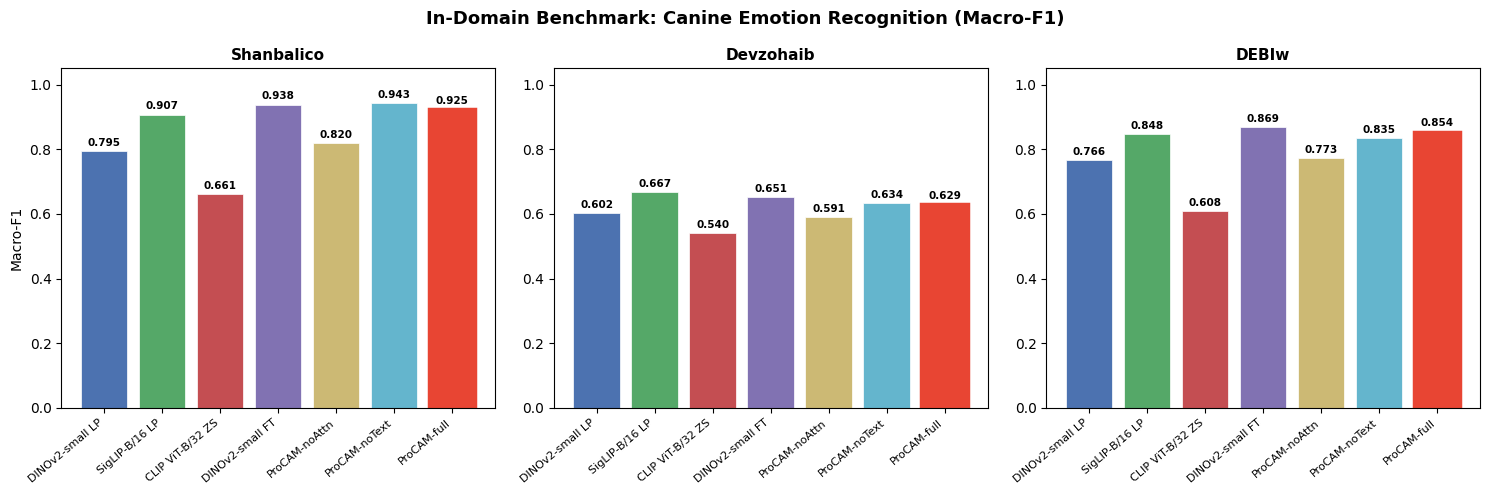

Fig 1 saved.


In [18]:
# ── Figure 1: In-domain bar chart ─────────────────────────────────────────
PALETTE = {
    'DINOv2-small LP':'#4C72B0','SigLIP-B/16 LP':'#55A868',
    'CLIP ViT-B/32 ZS':'#C44E52','DINOv2-small FT':'#8172B2',
    'ProCAM-noAttn':'#CCB974','ProCAM-noText':'#64B5CD','ProCAM-full':'#E84533',
}
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for ax, ds in zip(axes, ['Shanbalico','Devzohaib','DEBIw']):
    sub = all_indomain[all_indomain['dataset']==ds].copy()
    sub['model'] = pd.Categorical(sub['model'], categories=MODEL_ORDER, ordered=True)
    sub = sub.sort_values('model').dropna(subset=['macro_f1'])
    colors = [PALETTE.get(m,'#999') for m in sub['model']]
    bars = ax.bar(range(len(sub)), sub['macro_f1'], color=colors, edgecolor='white', lw=0.5)
    ax.set_xticks(range(len(sub)))
    ax.set_xticklabels(sub['model'], rotation=40, ha='right', fontsize=8)
    ax.set_title(ds, fontweight='bold', fontsize=11)
    ax.set_ylabel('Macro-F1' if ax==axes[0] else '')
    ax.set_ylim(0, 1.05)
    for bar, val in zip(bars, sub['macro_f1']):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.01,
                f'{val:.3f}', ha='center', va='bottom', fontsize=7.5, fontweight='bold')
    for bar, m in zip(bars, sub['model']):
        if m=='ProCAM-full': bar.set_edgecolor('#E84533'); bar.set_linewidth(2.5)

fig.suptitle('In-Domain Benchmark: Canine Emotion Recognition (Macro-F1)',
              fontsize=13, fontweight='bold')
plt.tight_layout()
fig.savefig(f'{CFG["out_dir"]}/fig_indomain_benchmark.pdf', dpi=200, bbox_inches='tight')
fig.savefig(f'{CFG["out_dir"]}/fig_indomain_benchmark.png', dpi=200, bbox_inches='tight')
plt.show(); print('Fig 1 saved.')


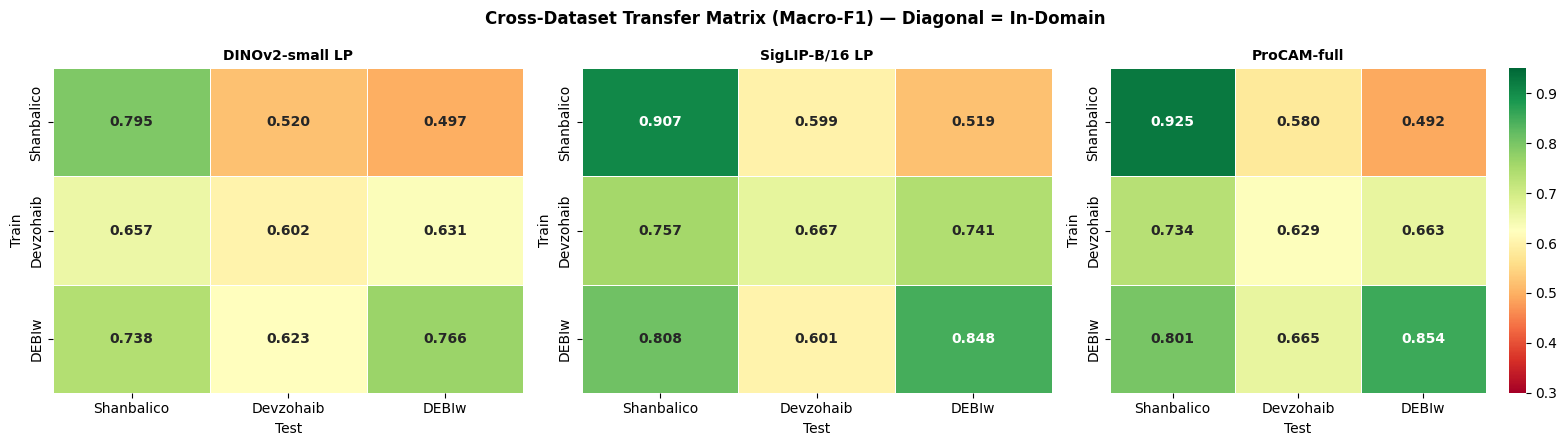

Fig 2 saved.


In [19]:
# ── Figure 2: Cross-dataset heatmap ───────────────────────────────────────
ds_order = ['Shanbalico','Devzohaib','DEBIw']
models_hm = ['DINOv2-small LP','SigLIP-B/16 LP','ProCAM-full']
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
for ax, mdl in zip(axes, models_hm):
    mat = pd.DataFrame(index=ds_order, columns=ds_order, dtype=float)
    for ds in ds_order:
        row = all_indomain[(all_indomain['dataset']==ds)&(all_indomain['model']==mdl)]
        if len(row): mat.loc[ds,ds] = row['macro_f1'].values[0]
    for _,row in cross_df[cross_df['model']==mdl].iterrows():
        if row['train'] in ds_order and row['test'] in ds_order:
            mat.loc[row['train'],row['test']] = row['macro_f1']
    mat = mat.astype(float)
    sns.heatmap(mat, ax=ax, annot=True, fmt='.3f', cmap='RdYlGn',
                vmin=0.3, vmax=0.95, linewidths=0.5,
                cbar=(ax==axes[-1]), mask=mat.isna(),
                annot_kws={'size':10,'weight':'bold'})
    ax.set_title(mdl, fontsize=10, fontweight='bold')
    ax.set_xlabel('Test'); ax.set_ylabel('Train')
fig.suptitle('Cross-Dataset Transfer Matrix (Macro-F1) — Diagonal = In-Domain',
              fontsize=12, fontweight='bold')
plt.tight_layout()
fig.savefig(f'{CFG["out_dir"]}/fig_cross_dataset_heatmap.pdf', dpi=200, bbox_inches='tight')
fig.savefig(f'{CFG["out_dir"]}/fig_cross_dataset_heatmap.png', dpi=200, bbox_inches='tight')
plt.show(); print('Fig 2 saved.')


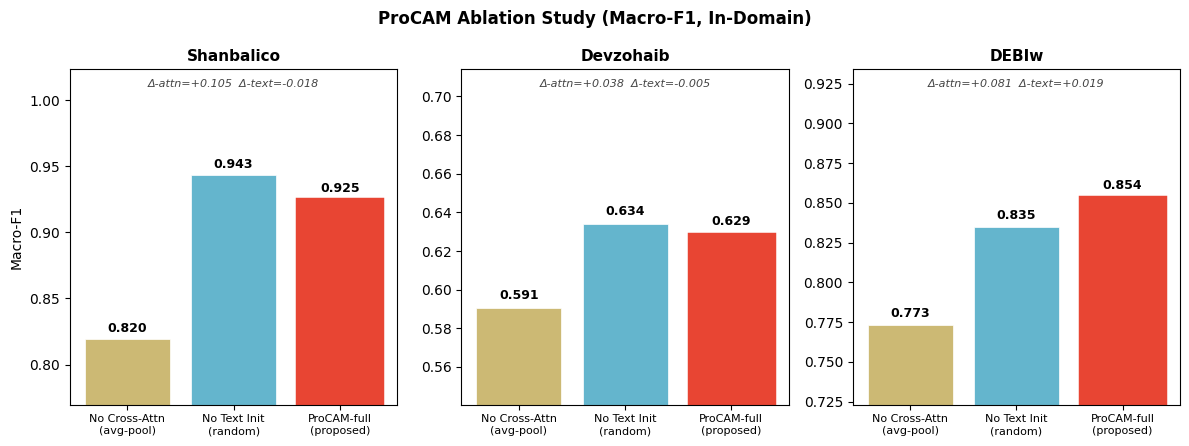

Fig 3 saved.


In [20]:
# ── Figure 3: Ablation bars ───────────────────────────────────────────────
abl = ['ProCAM-noAttn','ProCAM-noText','ProCAM-full']
abl_colors = [PALETTE[m] for m in abl]
abl_labels = ['No Cross-Attn\n(avg-pool)','No Text Init\n(random)','ProCAM-full\n(proposed)']
fig, axes = plt.subplots(1, 3, figsize=(12, 4.5))
for ax, ds in zip(axes, ['Shanbalico','Devzohaib','DEBIw']):
    sub = all_indomain[(all_indomain['dataset']==ds)&(all_indomain['model'].isin(abl))].copy()
    sub['model'] = pd.Categorical(sub['model'], categories=abl, ordered=True)
    sub = sub.sort_values('model')
    f1s = sub['macro_f1'].values
    bars = ax.bar(range(len(f1s)), f1s, color=abl_colors[:len(f1s)],
                   edgecolor='white', lw=0.5)
    if len(bars): bars[-1].set_edgecolor('#E84533'); bars[-1].set_linewidth(2.5)
    ax.set_xticks(range(len(f1s))); ax.set_xticklabels(abl_labels[:len(f1s)], fontsize=8)
    ax.set_title(ds, fontweight='bold', fontsize=11)
    ax.set_ylabel('Macro-F1' if ax==axes[0] else '')
    if len(f1s): ax.set_ylim(max(0,min(f1s)-0.05), min(1.05,max(f1s)+0.08))
    for bar,val in zip(bars,f1s):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.003,
                f'{val:.3f}', ha='center', va='bottom', fontsize=9, fontweight='bold')
    if len(f1s)==3:
        ax.text(0.5, 0.97, f'Δ-attn={f1s[2]-f1s[0]:+.3f}  Δ-text={f1s[2]-f1s[1]:+.3f}',
                transform=ax.transAxes, ha='center', va='top',
                fontsize=8, color='#444', style='italic')
fig.suptitle('ProCAM Ablation Study (Macro-F1, In-Domain)', fontsize=12, fontweight='bold')
plt.tight_layout()
fig.savefig(f'{CFG["out_dir"]}/fig_ablation.pdf', dpi=200, bbox_inches='tight')
fig.savefig(f'{CFG["out_dir"]}/fig_ablation.png', dpi=200, bbox_inches='tight')
plt.show(); print('Fig 3 saved.')


In [21]:
print('\nAll outputs:')
for f in sorted(Path(CFG['out_dir']).iterdir()):
    print(f'  {f.name}')



All outputs:
  cross_dataset_results.csv
  fig_ablation.pdf
  fig_ablation.png
  fig_cross_dataset_heatmap.pdf
  fig_cross_dataset_heatmap.png
  fig_indomain_benchmark.pdf
  fig_indomain_benchmark.png
  indomain_results_complete.csv
